# Разработка модели для поиска товаров по их визуальному сходству

## Описание задачи

Имеется 2 папки с изображениями одежды - `images` и `queries`.

необходимо для каждого изображения из папки queries найти наиболее визуально схожий товар из папки images при помощи предобученной свёрточной нейросети векторного поиска.

При помощи этой модели интернет-магазин сможет рекомендовать визуально схожие товары из каталога, что увеличит шанс покупки и лояльность пользователей.

Конечный файл должен иметь размерность `50` строк на `2` столбца с полями `ProductID` и `PredictProductID`.

Минимальное значение метрики Accuracy: `0.7`

In [26]:
import torch
import os
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [ ]:
vgg16 = models.vgg16(pretrained=True)   # Загрузим предобученную модель
vgg16.classifier = torch.nn.Sequential(*list(vgg16.classifier.children())[:-1]) # Переопределяем классификатор, исключив последний слой
vgg16.eval()    # Переводим vgg16 в режим инференса, чтобы не происходило накопление градиента

# Делаем трансформацию

# 0.66
# transform = transforms.Compose([   # Композиция
#     transforms.Resize((224,224)),   # Ресайз 
#     transforms.ToTensor(),          # В тензоры
#     transforms.Normalize(           # Нормализация значений пикселей
#         mean=[0.485, 0.456, 0.406], # среднее
#         std=[0.229, 0.224, 0.225]   # дисперсия
#         )
# ])

# 0.68
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # Оставляем ваш ресайз
#     transforms.Pad(padding=10, padding_mode='reflect'),  # Отражаем края (+10 пикселей)
#     transforms.RandomCrop(224),     # Режем обратно 224, но со случайным сдвигом в пределах 10px
#     transforms.RandomHorizontalFlip(p=0.5),  # Горизонтальное отражение (безопасно для 99% задач)
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# 0.72
transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.Pad(padding=15, padding_mode='reflect'),  # Увеличили с 10 до 15 пикселей
    transforms.RandomCrop(224),     
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


d:\Documents\Clouds\Google.Drive (kolcharma@gmail.com)\MachineLearning\Курс-симулятор\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Documents\Clouds\Google.Drive (kolcharma@gmail.com)\MachineLearning\Курс-симулятор\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
def get_feature_vector(image_path):
    """
    Извлекает вектор признаков из изображения с помощью предобученной модели VGG16.
    """
    image = Image.open(image_path).convert("RGB")    # Открываем изображение по указанному пути и преобразуем его в цветовой формат RGB 
    image = transform(image).unsqueeze(0)            # Применяем к изображению предопределённые преобразования
    with torch.no_grad():     # Отключаем вычисление градиентов для экономии памяти и ускорения работы (режим инференса)
        features = vgg16(image) # Пропускаем изображение через предобученную модель VGG16 и получаем выходной тензор признаков
    return features.squeeze().numpy()

def display_images(query_image_path, similar_image_path, similarity_score):
    """
    Вывод изображения из запроса и его сравнение с наиболее похожим объектом
    """
    query_image = Image.open(query_image_path)
    similar_image = Image.open(similar_image_path)

    fig, axes = plt.subplots(1,2, figsize=(10,5))

    axes[0].imshow(query_image)
    axes[0].set_title('Запрос')
    axes[0].axis('off')

    axes[1].imshow(similar_image)
    axes[1].set_title(f'Наиболее похожий объект с score = {similarity_score:.2f}')
    axes[1].axis('off')

    plt.show()

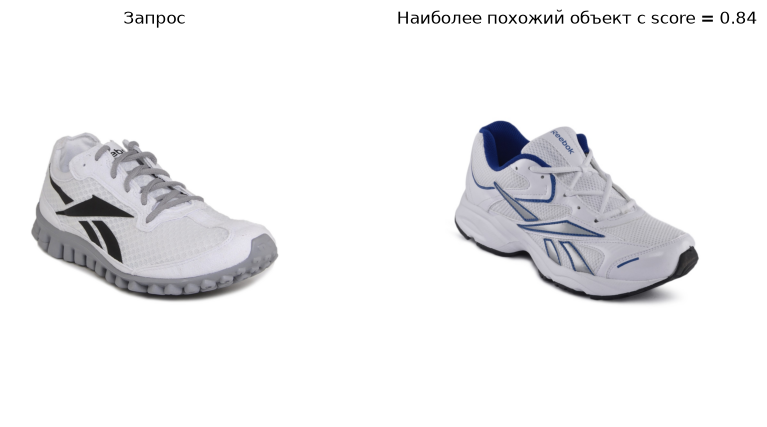

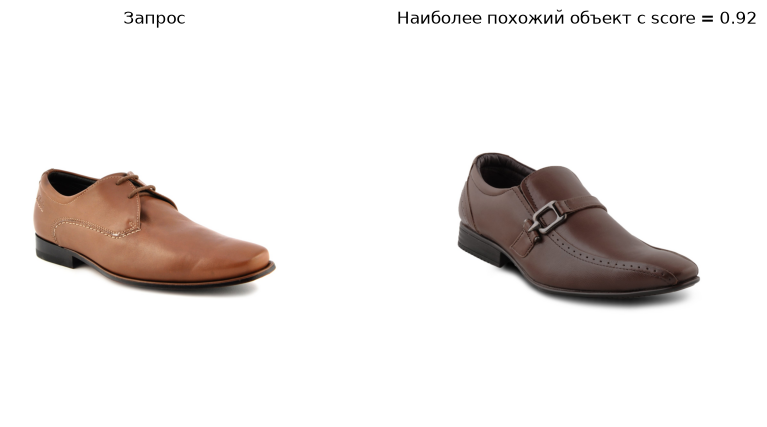

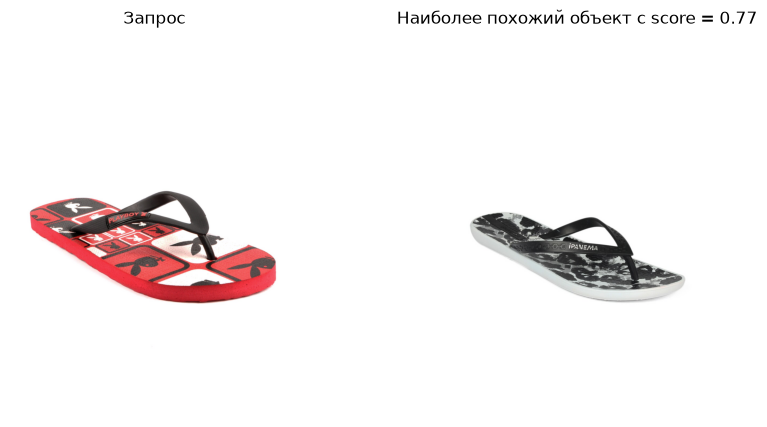

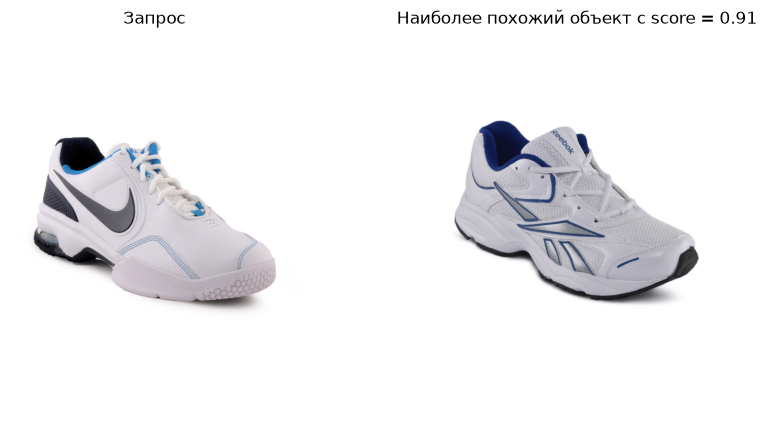

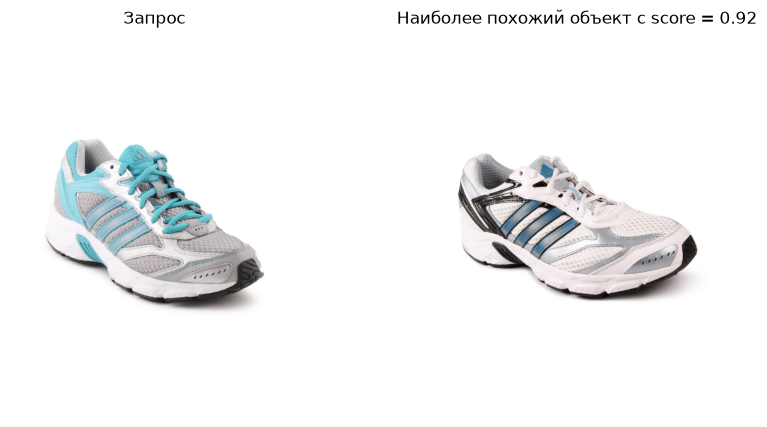

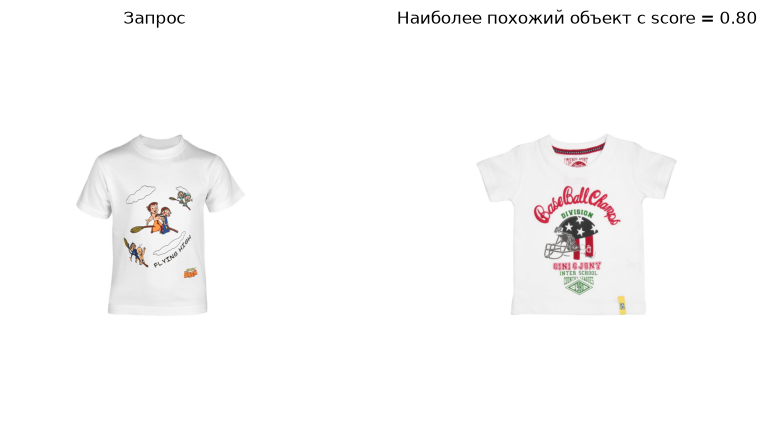

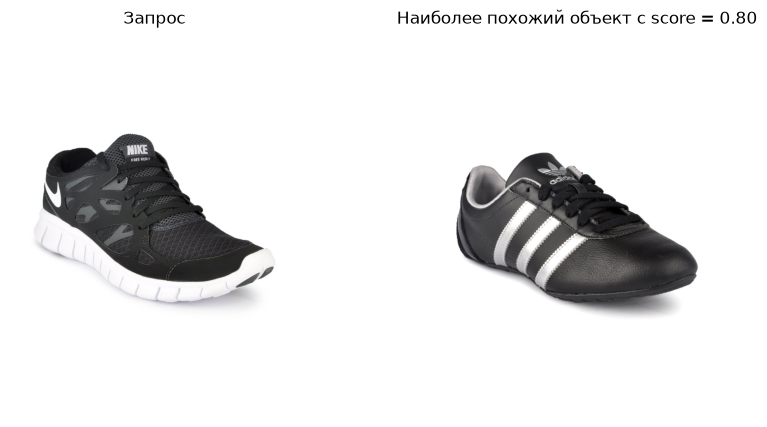

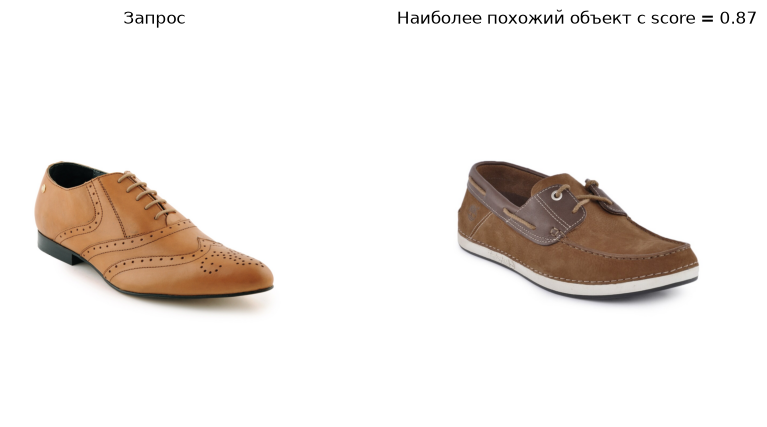

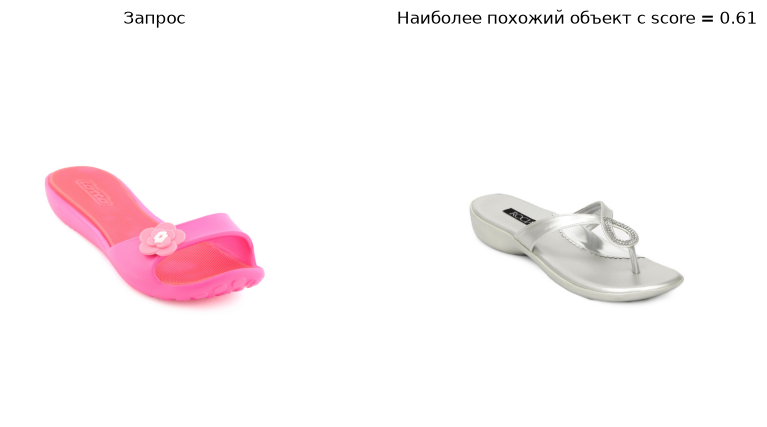

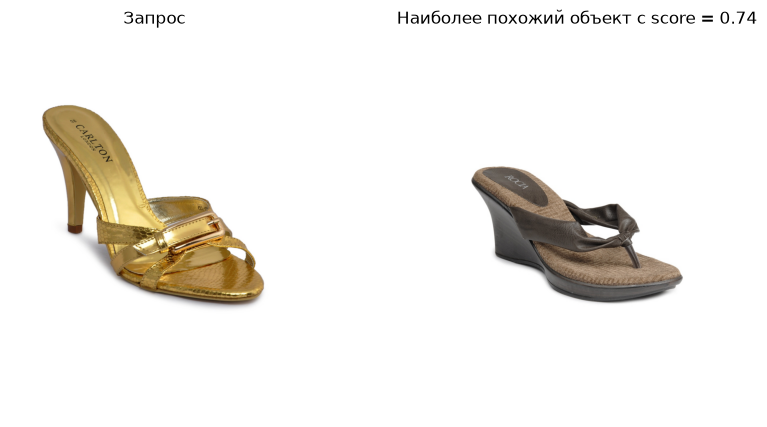

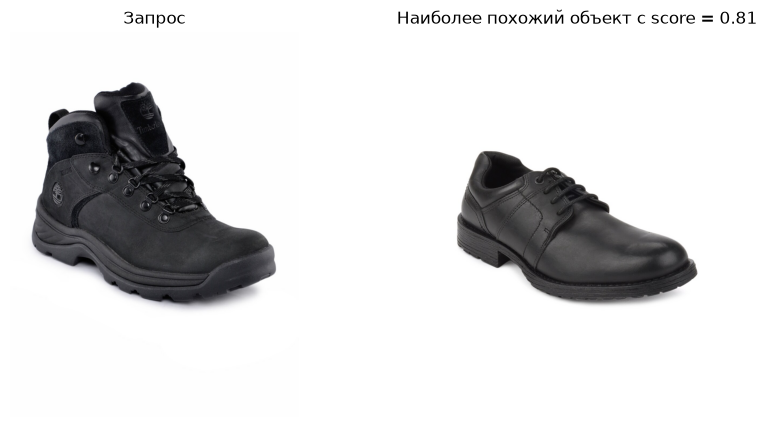

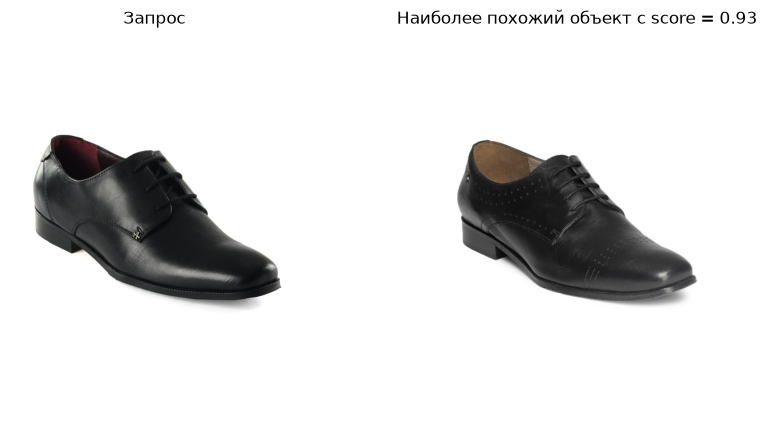

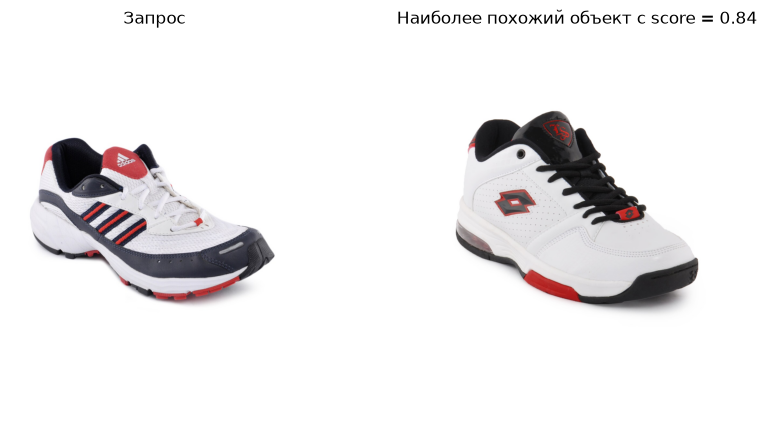

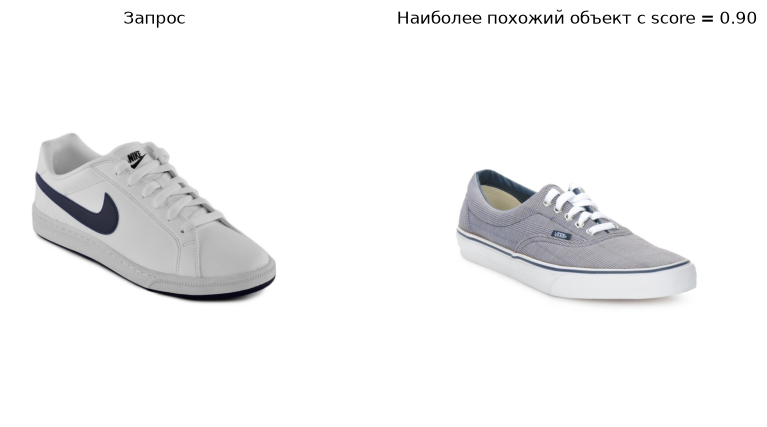

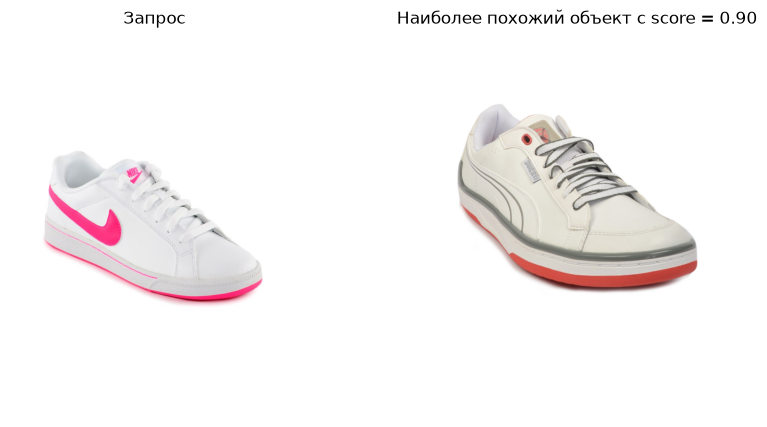

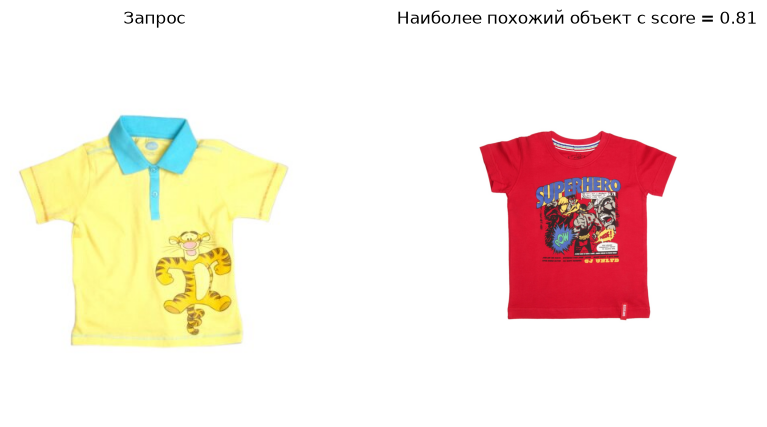

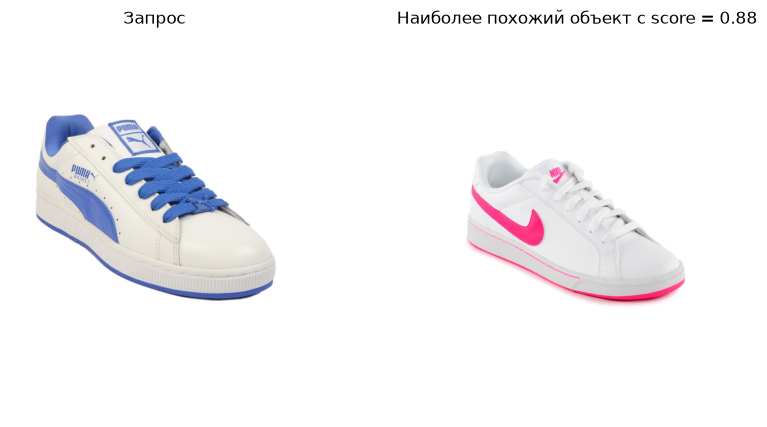

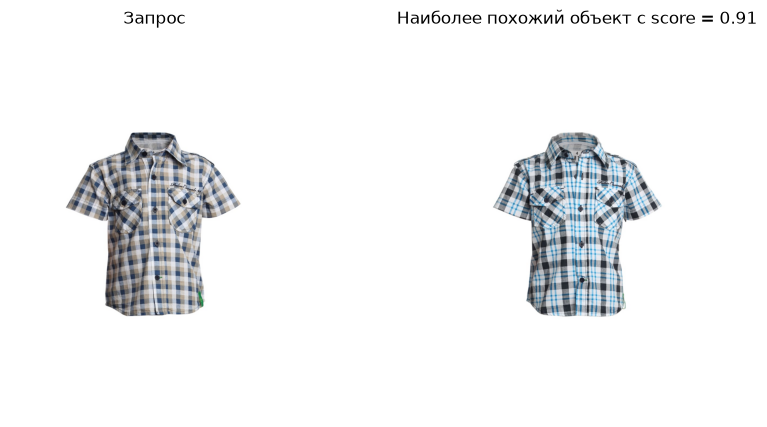

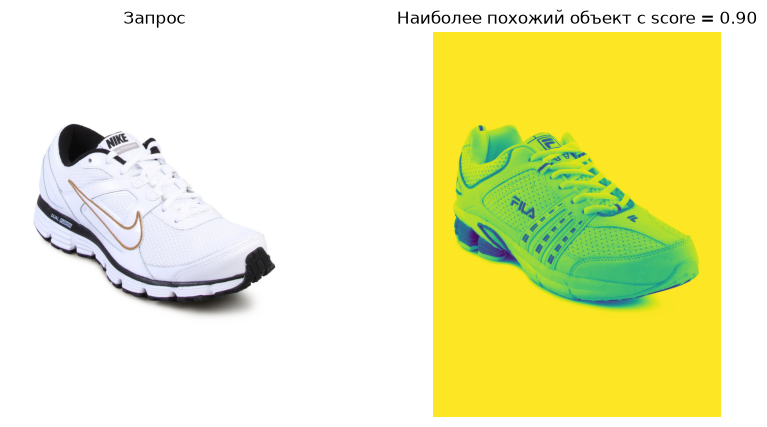

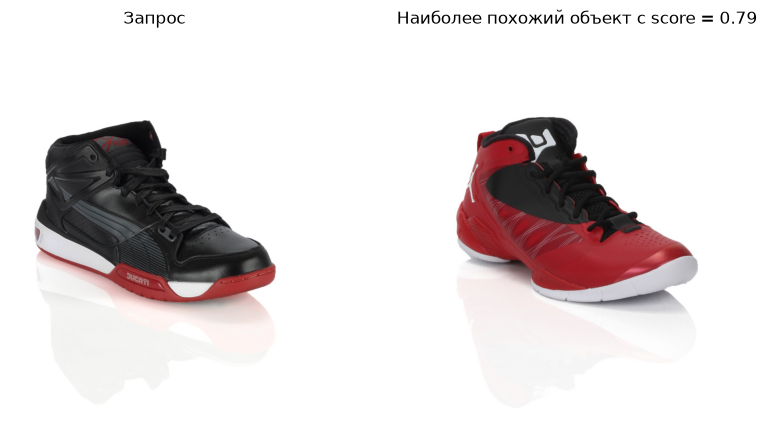

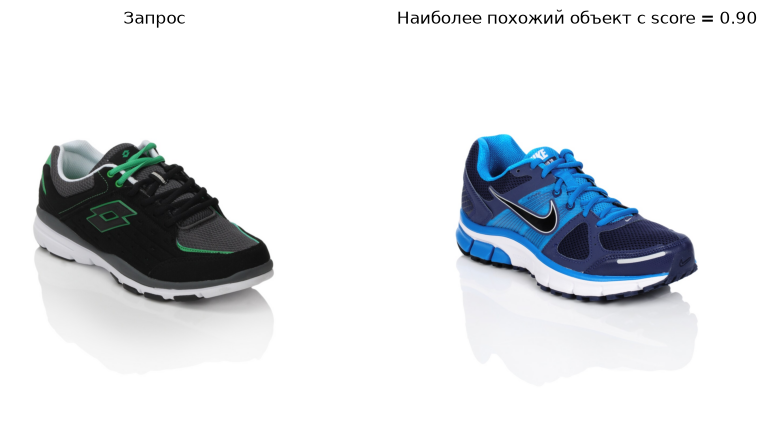

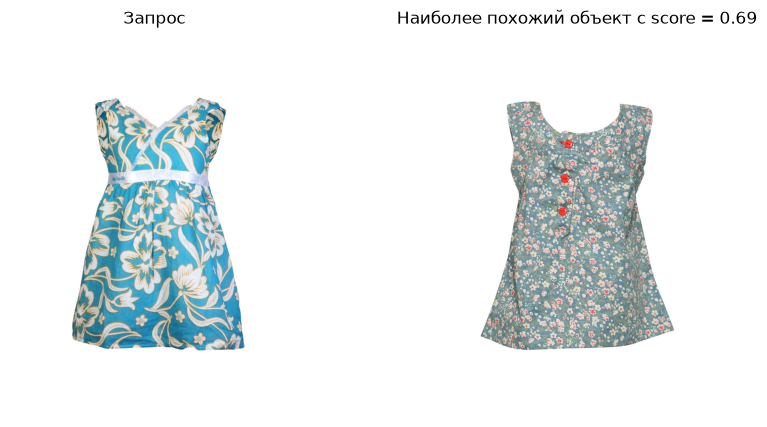

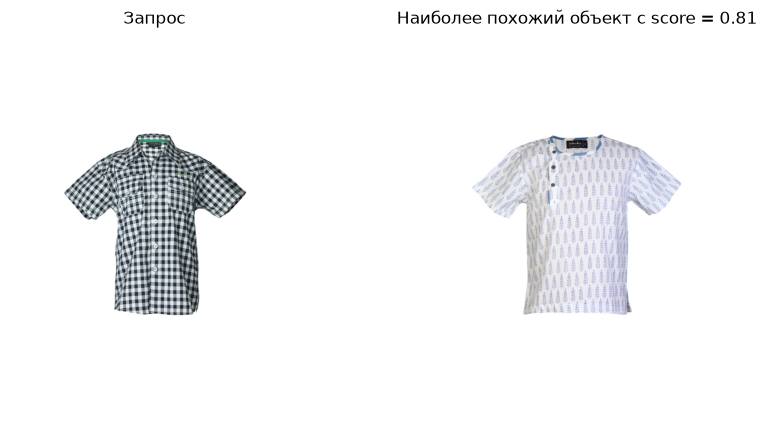

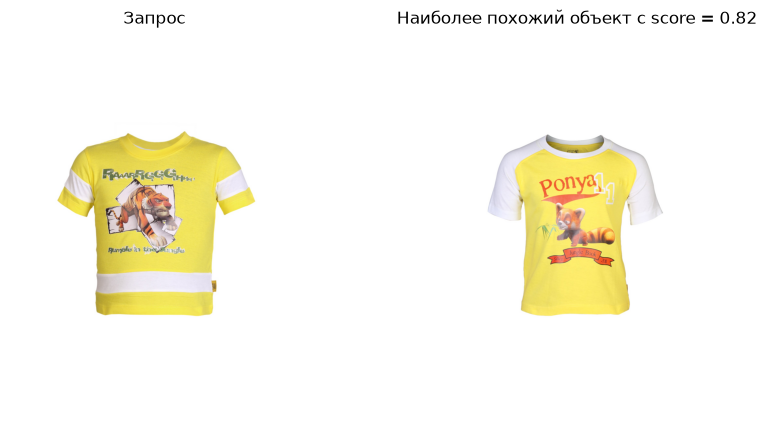

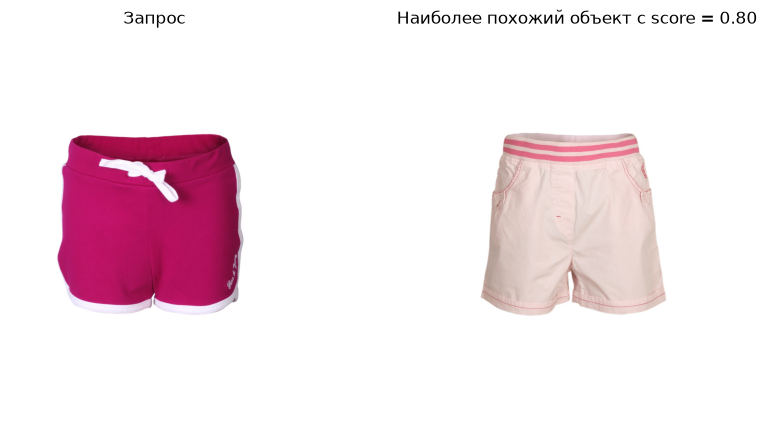

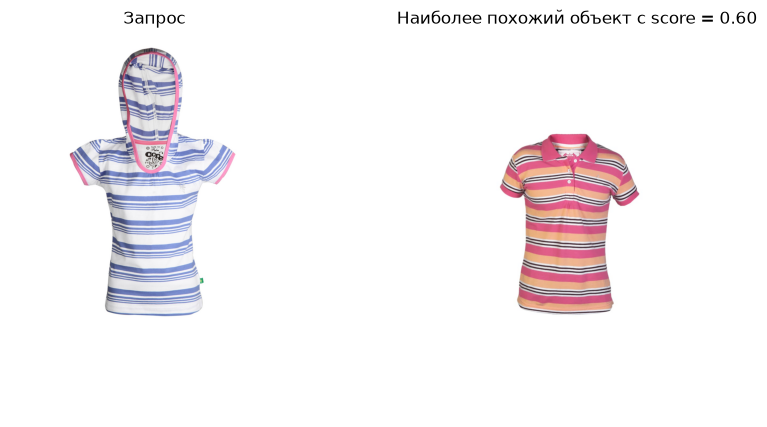

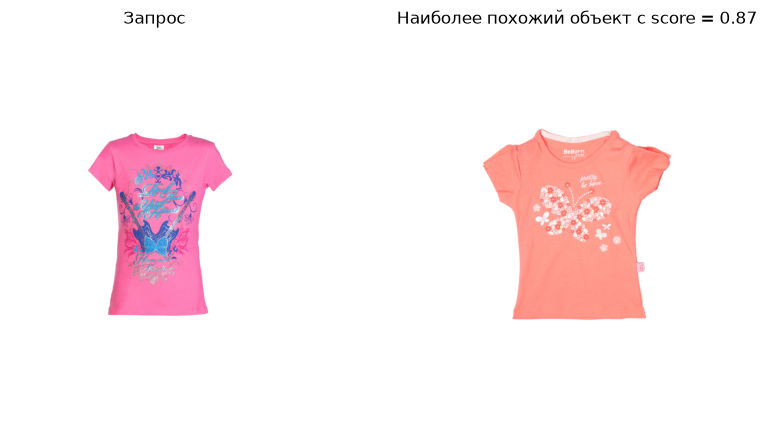

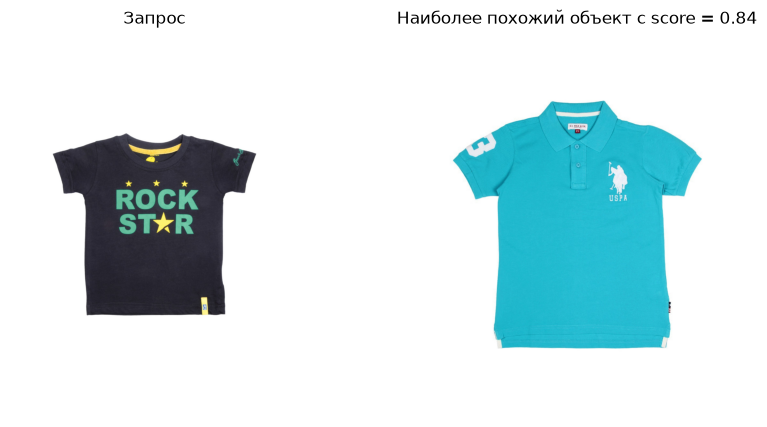

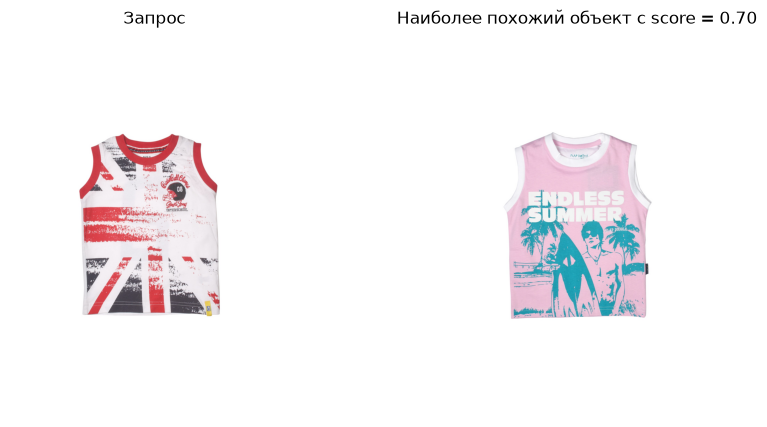

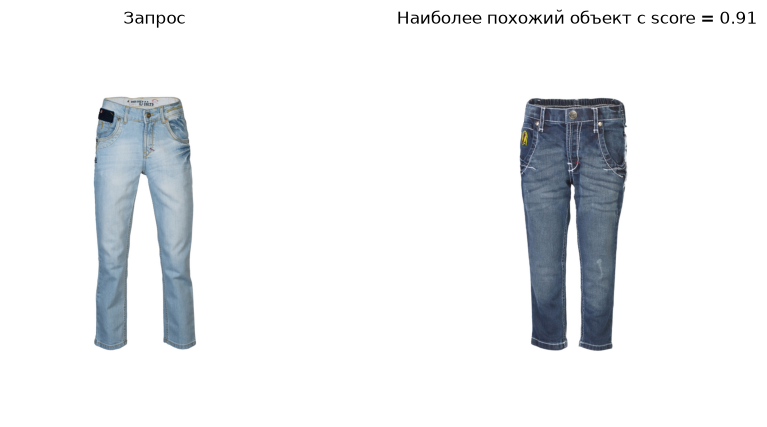

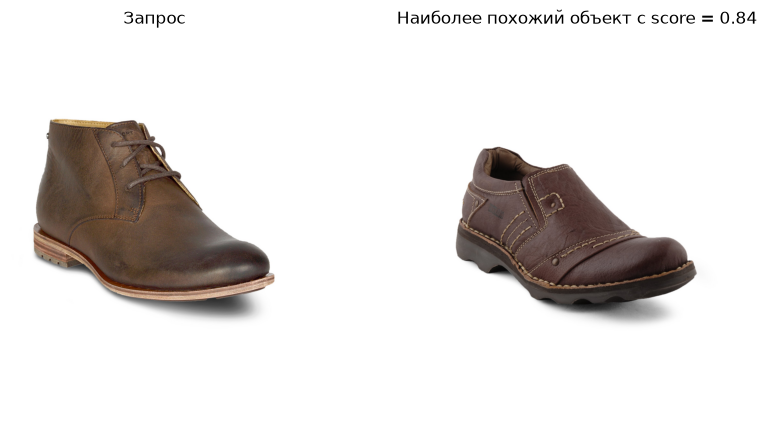

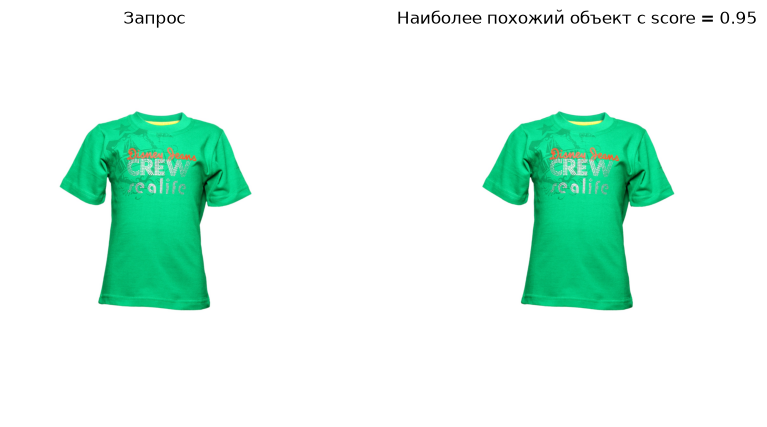

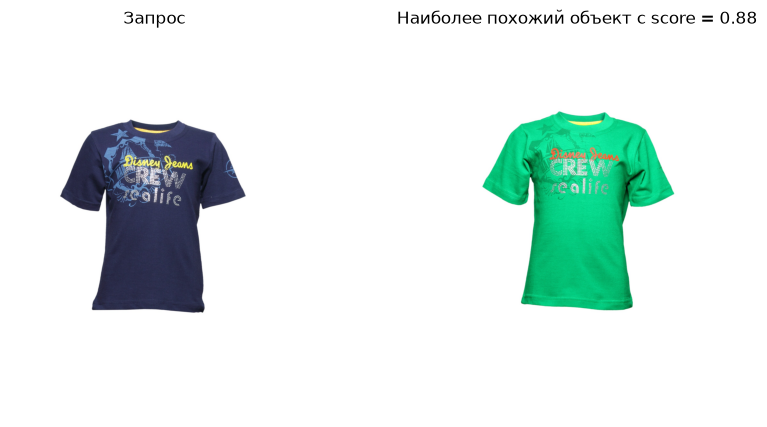

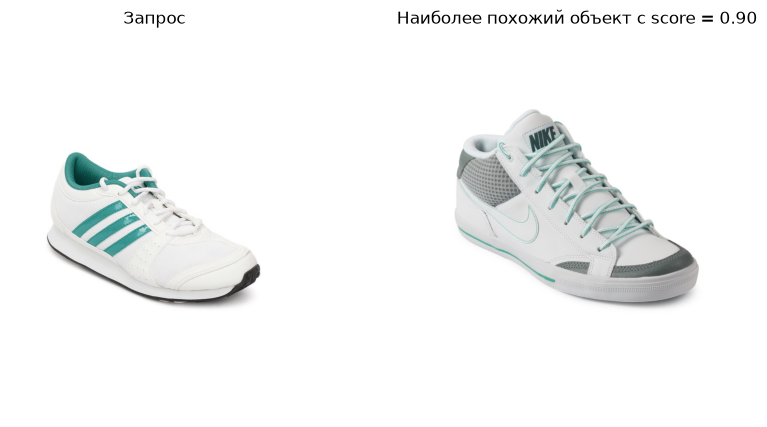

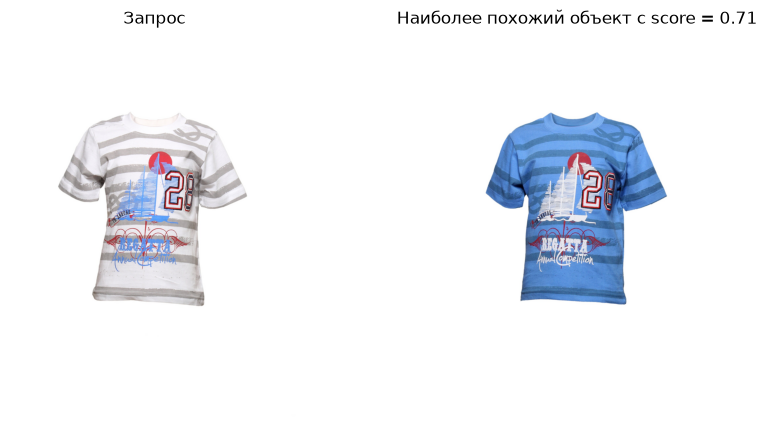

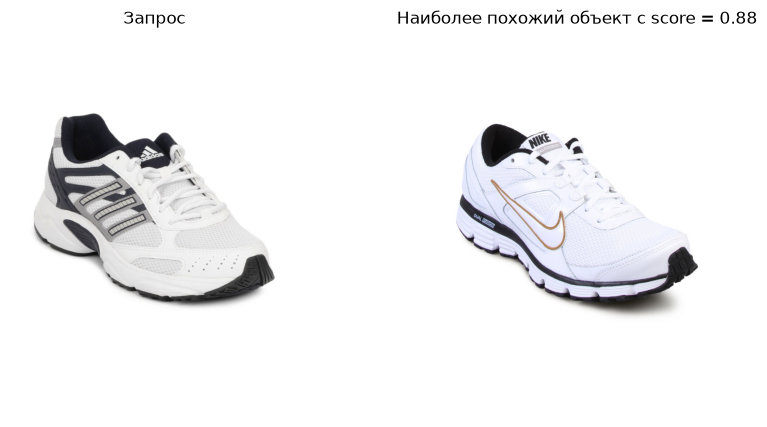

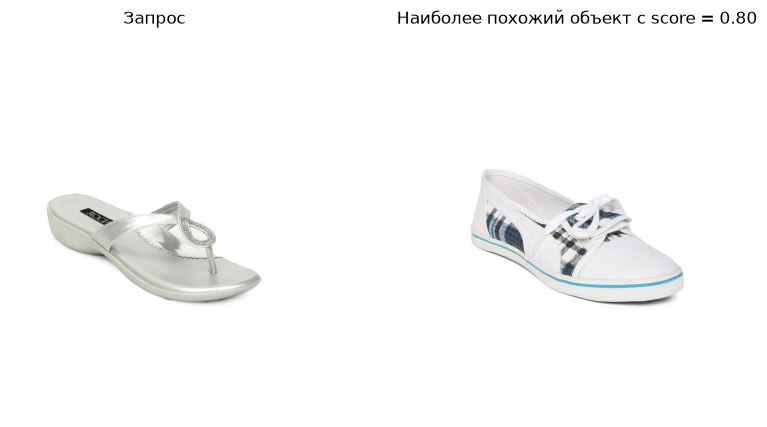

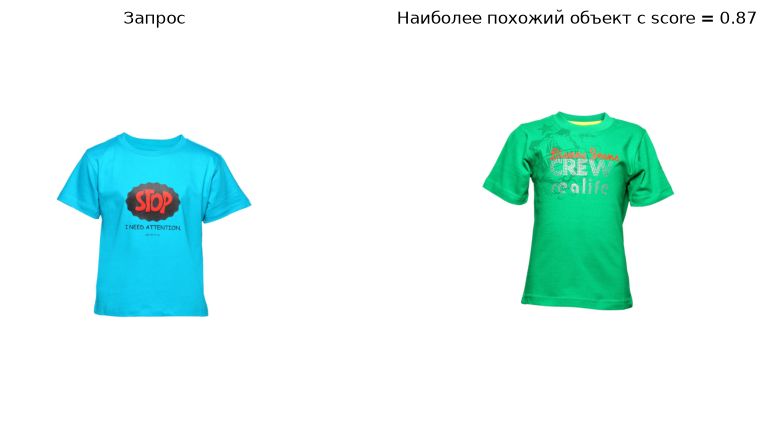

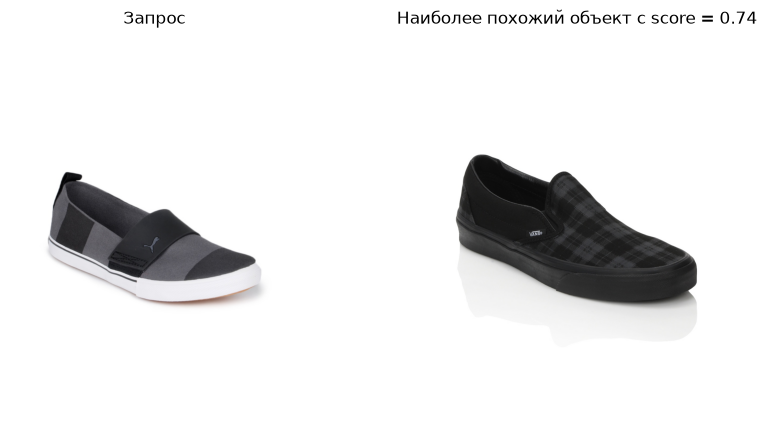

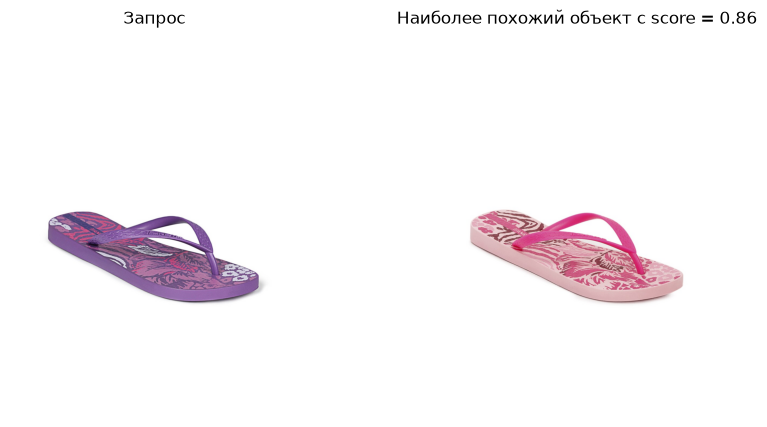

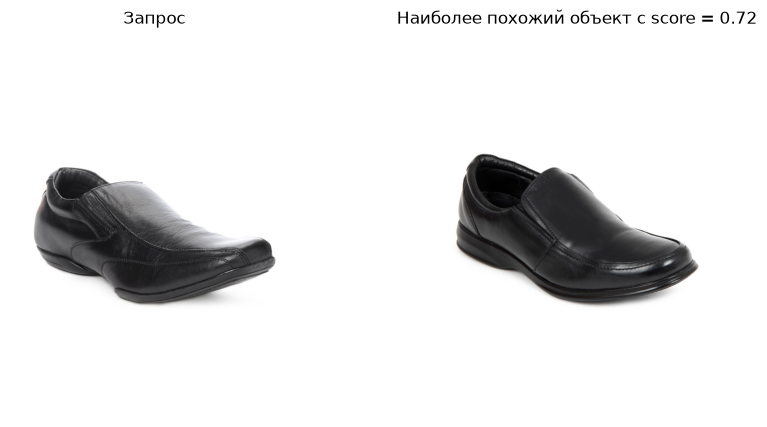

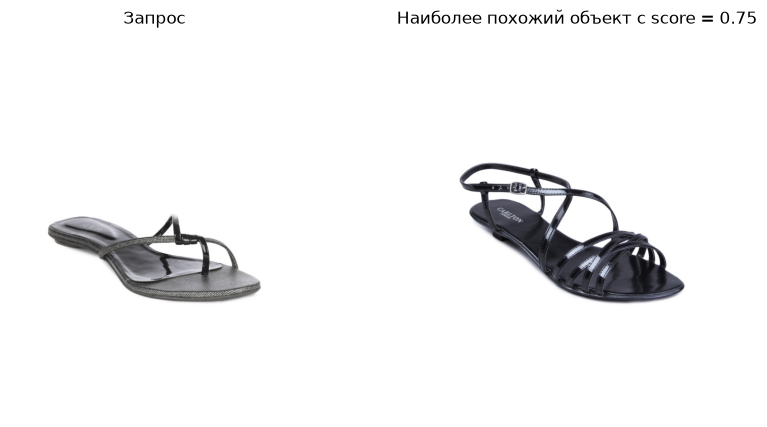

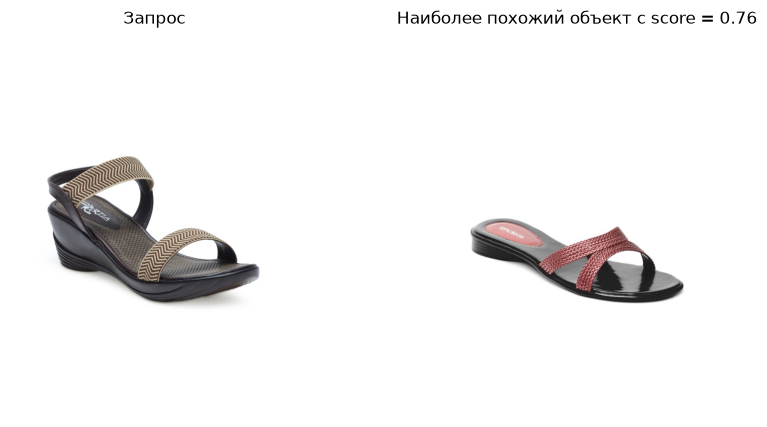

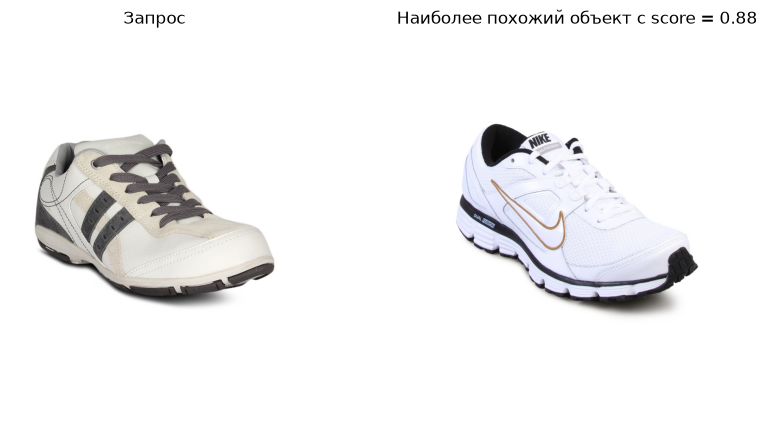

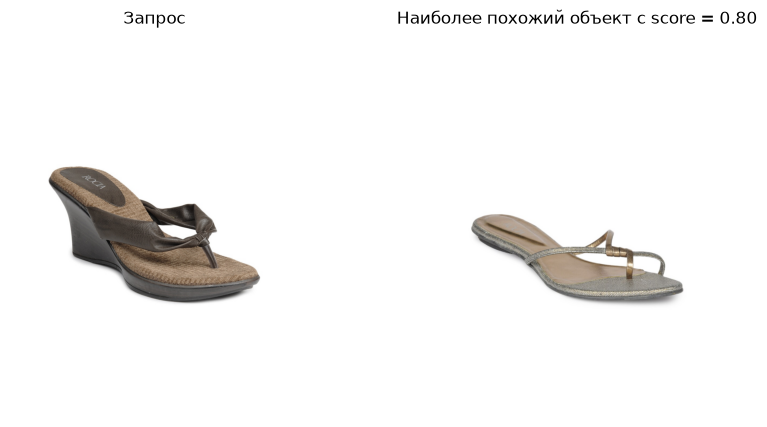

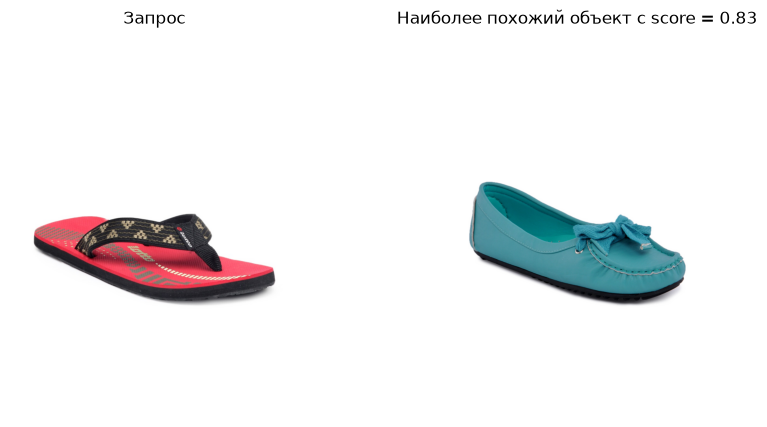

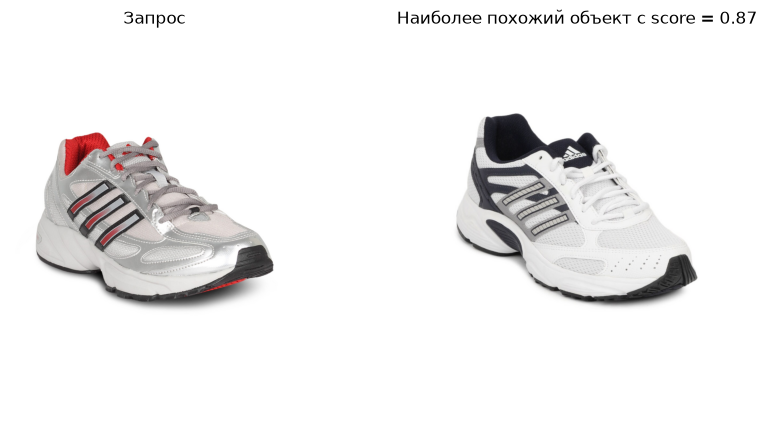

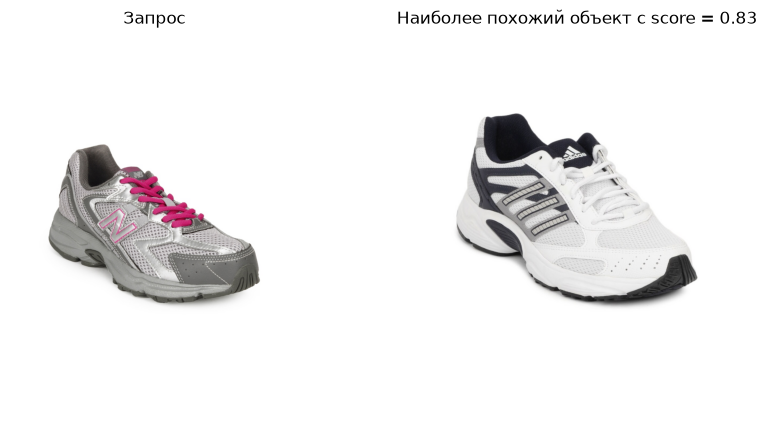

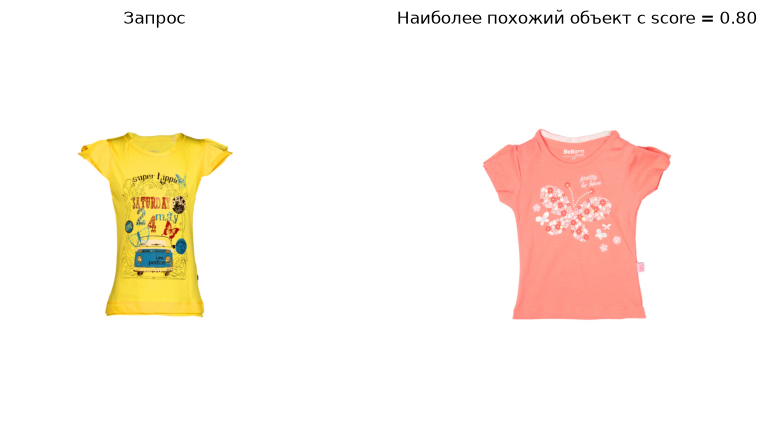

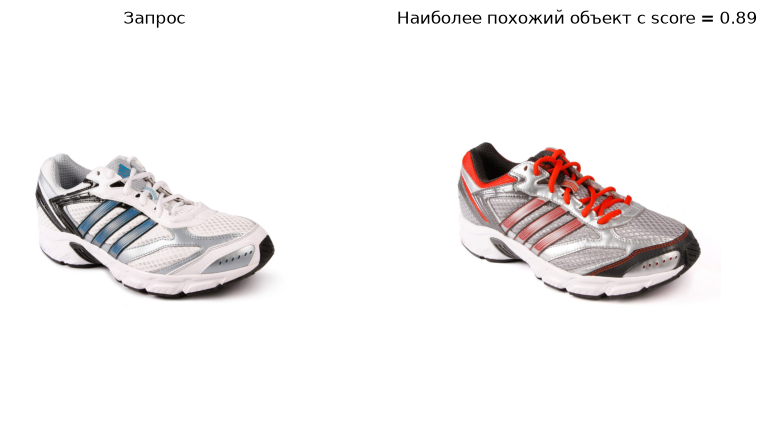

In [29]:
image_dir = 'images'
query_dir = 'queries'
image_files = [f for f in os.listdir(image_dir)]
query_files = [f for f in os.listdir(query_dir)]

image_paths = [os.path.join(image_dir, f) for f in image_files]
query_paths = [os.path.join(query_dir, f) for f in query_files]

# Получаем ID из имен файлов
image_ids = [os.path.splitext(f)[0] for f in image_files]  # Убираем .jpg
query_ids = [os.path.splitext(f)[0] for f in query_files]

feature_vectors = [get_feature_vector(img) for img in image_paths]

data = []

for query_idx, query in enumerate(query_paths):
    query_vector = get_feature_vector(query)
    query_id = query_ids[query_idx]
    
    similarities = cosine_similarity([query_vector], feature_vectors)[0]
    
    # Создаем копию
    similarities_filtered = similarities.copy()
    
    # Исключаем изображения с тем же ID
    for i, img_id in enumerate(image_ids):
        if img_id == query_id:
            similarities_filtered[i] = -1
    
    # Также можно исключить слишком высокую схожесть (если есть почти дубликаты)
    # similarities_filtered[similarities_filtered >= 0.99] = -1
    
    most_similar_idx = np.argmax(similarities_filtered)
    similar_image, similar_score = image_paths[most_similar_idx], similarities[most_similar_idx]
    
    display_images(query, similar_image, similar_score)
    data.append([query, similar_image])

res = pd.DataFrame(data, columns=["ProductID", "PredictProductID"])


In [30]:
# Извлекаем только числа
res['ProductID'] = res['ProductID'].str.extract(r'(\d+)').astype(int)
res['PredictProductID'] = res['PredictProductID'].str.extract(r'(\d+)').astype(int)

In [31]:
res.head()

,ProductID,PredictProductID
0,10097,22959
1,10294,9038
2,11856,41940
3,12705,22959
4,13682,9052


In [32]:
res.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ProductID         50 non-null     int64
 1   PredictProductID  50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


In [33]:
# Сохраняем результат
res.to_csv('result.csv', index=False)

Accuracy: 0.72